# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [22]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** How are emissions and GDP tied together and how does changing our emissions affect GDP given our current infrastructure?

**This is a prediction (umbrella) problem because:** Emissions are often seen as a necessary byproduct of economic growth. Parties pollute because it is cheaper and more efficient than not. Countries with higher emissions tend to have higher GDPs. It can be representative of productivity and development.

**The decision this enables:** Countries, economists, and firms around the world would benefit from this data. They are able to see what sectors are causing the most direct impact on the climate and determine if the impact is worth the gain. Environmental scientists often say we are close to a point of no return, where we will not be able to stop the damage done, but with this we will be able to see what sectors are causing the most damage and which are worth public cost.

**Dataset:** Data on CO2 and Greenhouse Gas Emissions
- **Source:** Our World in Data (URL: https://github.com/owid/co2-data/tree/master)
- **N =** 50411
- **Features =** 'country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita', 'oil_co2', 'oil_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'primary_energy_consumption', 'share_global_cement_co2', 'share_global_co2', 'share_global_co2_including_luc', 'share_global_coal_co2', 'share_global_cumulative_cement_co2', 'share_global_cumulative_co2', 'share_global_cumulative_co2_including_luc', 'share_global_cumulative_coal_co2', 'share_global_cumulative_flaring_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_luc_co2', 'share_global_cumulative_oil_co2', 'share_global_cumulative_other_co2', 'share_global_flaring_co2', 'share_global_gas_co2', 'share_global_luc_co2', 'share_global_oil_co2', 'share_global_other_co2', 'share_of_temperature_change_from_ghg', 'temperature_change_from_ch4', 'temperature_change_from_co2', 'temperature_change_from_ghg', 'temperature_change_from_n2o', 'total_ghg', 'total_ghg_excluding_lucf', 'trade_co2', 'trade_co2_share'

- **Target variable =** 'gdp'
- **Access date:** 4.19.2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [57]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

# df = pd.read_csv('your_data.csv')
# df = pd.read_csv('https://example.com/data.csv')

# Uncomment and modify one of the lines above
df_raw = pd.read_csv('https://raw.githubusercontent.com/owid/co2-data/refs/heads/master/owid-co2-data.csv')

# Quick look
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw

Shape: (50411, 79)
Columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957


### 2.2 Basic Description

In [58]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017453e+07,3.300495e+11,7.890109,0.060013,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308433e+08,3.086383e+12,62.988171,0.123562,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291594e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.076250,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


### 2.3 Missing Data Assessment

Missing data (%) by column:
share_global_cumulative_other_co2       0.956954
share_global_other_co2                  0.956954
other_co2_per_capita                    0.947254
cumulative_other_co2                    0.935451
other_industry_co2                      0.935451
                                          ...   
population                              0.183373
temperature_change_from_ghg             0.181964
share_of_temperature_change_from_ghg    0.181964
temperature_change_from_co2             0.181964
iso_code                                0.157327
Length: 77, dtype: float64
Percent of Total Data Missing:  54.25 %


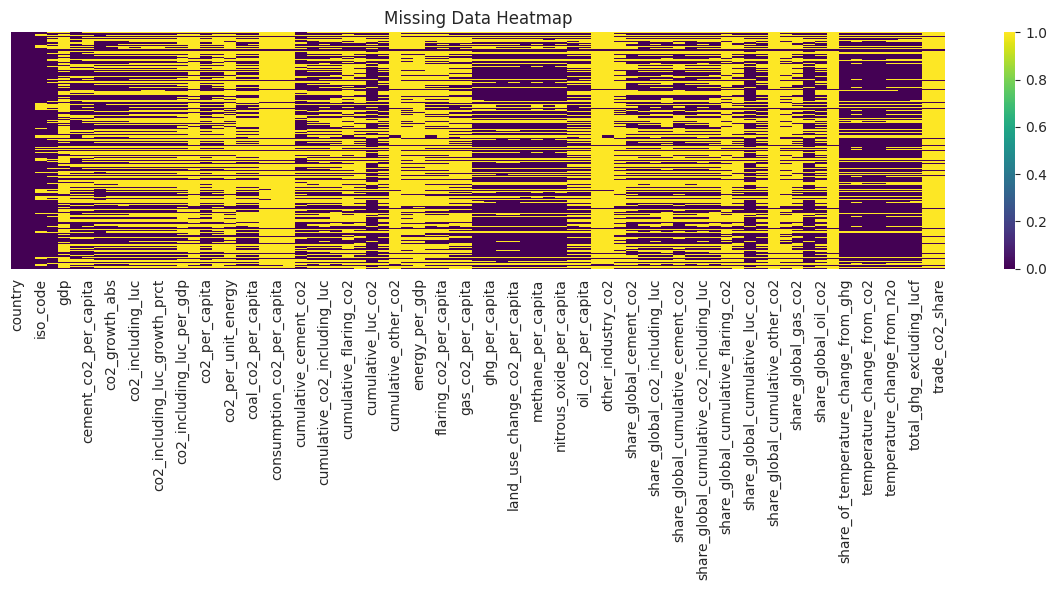

In [59]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df_raw.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])
print('Percent of Total Data Missing: ', round(sum(missing_pct[missing_pct > 0])/77*100, 2), '%')

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** I believe the data is MNAR. Most of the missing values are likely to be countries or regions that have poor records and low means to collect records. Also, much of the missing data could be older data that is uncollectable since the dataset starts in 1750, but most emission data was not measured until 1990.

It seems that there is a lot of missing data and it may be hard to bridge the gap between what is avaiable and what I need. I think for now I will drop countries that have large amounts of missing data, fill blanks with averages between the years available, and flag them as filled. It may be helpful to find another data source that could fill in the gaps.

In [60]:
# @title
import pandas as pd
import numpy as np


# ─────────────────────────────────────────────────────────────────────────────
# Configuration — edit these if you want to tighten or loosen the thresholds
# ─────────────────────────────────────────────────────────────────────────────

# Year range: pre-1990 energy and GDP coverage is too thin to be useful.
# OWID's co2 series goes back to 1750, but energy_per_capita / gdp only
# become reasonably populated from 1990.
START_YEAR = 1990
END_YEAR   = 2024   # update if you pull a newer file

# Drop any column where more than this share of cells are NaN.
# 50% is deliberately generous; in practice only the "other_industry" family
# of columns exceeds it in this dataset.
COLUMN_NAN_THRESHOLD = 0.50

# Drop any country where more than this share of FOCUS_COLS cells are NaN.
# 50% drops only the micro-territories with structurally absent energy/GDP data.
# Lowering to 0.40 would additionally remove East Timor and New Caledonia.
# Raising to 0.70 would keep Bermuda and the Faroe Islands at the cost of
# having nearly-empty rows in your panel.
COUNTRY_NAN_THRESHOLD = 0.50

# The columns used to evaluate per-country missingness (Stage 2).
# These are the variables most commonly used in energy-GDP-emissions regressions.
# They also represent the columns with the widest coverage, so they give the
# most honest signal about whether a country has usable data.
FOCUS_COLS = [
    'co2',
    'co2_per_capita',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp',
    'gdp',
    'methane',
    'nitrous_oxide',
    'total_ghg',
    'coal_co2',
    'gas_co2',
    'oil_co2',
]


# ─────────────────────────────────────────────────────────────────────────────
# Stage 1a: Remove non-country entities
# ─────────────────────────────────────────────────────────────────────────────

def remove_aggregates(df: pd.DataFrame) -> pd.DataFrame:
    """
    OWID stores regional aggregates ("World", "Africa", "High-income
    countries", "European Union (27)", etc.) alongside real countries in the
    same 'country' column.  They are identifiable by a missing iso_code.

    Keeping them would cause double-counting in any regression or aggregate
    statistic. This filter removes all 36 aggregate entities, leaving 218
    real countries.
    """
    before = df['country'].nunique()

    # iso_code is NaN for all OWID-constructed aggregates, but not for any
    # real country (including small states like Kosovo which gets "OWID_KOS").
    df_countries = df[df['iso_code'].notna()].copy()

    after = df_countries['country'].nunique()
    print(f'[Stage 1a] Removed aggregates: {before} -> {after} entities '
          f'({before - after} non-country rows removed)')
    return df_countries


# ─────────────────────────────────────────────────────────────────────────────
# Stage 1b: Restrict to the usable year window
# ─────────────────────────────────────────────────────────────────────────────

def restrict_years(df: pd.DataFrame,
                   start: int = START_YEAR,
                   end: int = END_YEAR) -> pd.DataFrame:
    """
    Pre-1990 coverage of energy and GDP variables is sparse enough that
    imputing it would mean largely fabricating data. The co2 and co2_per_capita
    series are fine from the 1800s, but for a joint energy-GDP-emissions model
    1990 onward is the appropriate window.

    Adjust START_YEAR if your analysis is co2-only and you want historical depth.
    """
    df_window = df[(df['year'] >= start) & (df['year'] <= end)].copy()
    print(f'[Stage 1b] Year window {start}-{end}: {len(df_window):,} rows')
    return df_window


# ─────────────────────────────────────────────────────────────────────────────
# Stage 1c: Drop columns with excessive missingness
# ─────────────────────────────────────────────────────────────────────────────

def drop_sparse_columns(df: pd.DataFrame,
                        threshold: float = COLUMN_NAN_THRESHOLD) -> pd.DataFrame:
    """
    Drop columns where more than `threshold` of cells are NaN.

    In this dataset at the 1990–2024 country-only window, the only columns
    that exceed 50% missing are the five 'other_industry' variants:
        - other_industry_co2
        - other_co2_per_capita
        - cumulative_other_co2
        - share_global_other_co2
        - share_global_cumulative_other_co2

    These columns are not useful for energy-GDP-emissions analysis and have
    no established interpolation basis, so dropping them is appropriate.
    All other columns, including the full suite of sector-level CO2 series,
    GHG totals, and temperature attribution metrics, are kept.
    """
    # Compute missingness share per column
    miss_share = df.isna().mean()
    drop_cols  = miss_share[miss_share > threshold].index.tolist()

    # Never drop the identifier columns regardless of missingness
    keep_always = ['country', 'year', 'iso_code']
    drop_cols   = [c for c in drop_cols if c not in keep_always]

    df_trimmed = df.drop(columns=drop_cols)
    print(f'[Stage 1c] Dropped {len(drop_cols)} columns (>{threshold:.0%} missing):')
    for c in drop_cols:
        print(f'          {c}: {miss_share[c]:.1%}')
    print(f'          Remaining columns: {df_trimmed.shape[1]}')
    return df_trimmed


# ─────────────────────────────────────────────────────────────────────────────
# Stage 2: Drop countries with excessive missingness on focus columns
# ─────────────────────────────────────────────────────────────────────────────

def drop_sparse_countries(df: pd.DataFrame,
                          focus: list = FOCUS_COLS,
                          threshold: float = COUNTRY_NAN_THRESHOLD) -> pd.DataFrame:
    """
    For each country, compute the average NaN rate across FOCUS_COLS.
    Drop countries above `threshold`.

    At 50%, only 17 entities are removed, all of which are micro-territories
    or special cases with no energy or GDP statistical infrastructure:
        Marshall Islands, Anguilla, Sint Maarten, Bonaire/Sint Eustatius/Saba,
        Curacao, Montserrat, Saint Pierre and Miquelon, Faroe Islands,
        French Polynesia, Greenland, Bermuda, Palau, Palestine, New Caledonia,
        East Timor, Antarctica, Vatican/Monaco/San Marino (zero data at all).

    All low-income countries are retained. Chad, Burundi, Guinea-Bissau, and
    similar countries with thin but real statistical records are all under 20%
    missing on focus columns and pass this filter.
    """
    # Only evaluate columns that actually exist in df after the column drop
    focus_present = [c for c in focus if c in df.columns]

    # Mean missingness per country across all focus columns and all years
    country_miss = (
        df.groupby('country')[focus_present]
          .apply(lambda g: g.isna().to_numpy().mean())
    )

    drop_countries = country_miss[country_miss > threshold].index.tolist()
    keep_countries = country_miss[country_miss <= threshold].index.tolist()

    df_filtered = df[df['country'].isin(keep_countries)].copy()

    print(f'[Stage 2]  Country threshold >{threshold:.0%} missing on focus cols:')
    print(f'           Dropped {len(drop_countries)} countries, kept {len(keep_countries)}')
    print(f'           Dropped: {sorted(drop_countries)}')
    return df_filtered


# ─────────────────────────────────────────────────────────────────────────────
# Stage 3: Linear interpolation within each country's time series
# ─────────────────────────────────────────────────────────────────────────────

def interpolate_panel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fill remaining NaN cells using linear interpolation within each country's
    time series.

    For a single missing year between two observed values, this is exactly the
    arithmetic mean of the year before and the year after. For a gap of k years,
    it is the linear interpolant between the nearest observed values on each side,
    which is the generalized form of that same average.

    Implementation notes:
    - Sorted by (country, year) before interpolation to ensure correct ordering.
    - `limit_area='inside'` prevents the interpolator from extrapolating beyond
      the first and last observed value in a country's series. Edge NaNs (e.g.
      a country that starts reporting in 1995 will not have 1990–1994 fabricated).
    - Only numeric columns are interpolated; 'country', 'year', 'iso_code' are
      left untouched.
    - The interpolation is applied per country group so that Germany's series
      never bleeds into Ghana's.

    After this stage, roughly 11% of cells are filled (mostly sporadic GDP and
    energy gaps). A small residual of edge NaNs will remain for countries that
    simply never reported certain variables; these are left as NaN because there
    is no principled basis for filling them.
    """
    # Sort so years are in order within each country (required for interpolation)
    df = df.sort_values(['country', 'year']).reset_index(drop=True)

    # Identify which columns can be interpolated (numeric only)
    id_cols      = ['country', 'year', 'iso_code']
    numeric_cols = [c for c in df.columns if c not in id_cols
                    and pd.api.types.is_numeric_dtype(df[c])]

    # Record pre-interpolation NaN positions to quantify what was filled
    nan_before = df[numeric_cols].isna().sum().sum()

    # Iterate over each country by index rather than using groupby.apply.
    # pandas 3.0 changed groupby.apply to set the groupby key as the index,
    # which drops it from the columns. Direct index-based assignment is
    # both version-safe and slightly faster for this use case.
    for _, idx in df.groupby('country').groups.items():
        df.loc[idx, numeric_cols] = (
            df.loc[idx, numeric_cols]
              .interpolate(
                  method='linear',
                  limit_direction='both',
                  limit_area='inside'   # do not extrapolate beyond observed range
              )
              .values
        )

    nan_after  = df[numeric_cols].isna().sum().sum()
    cells_filled = nan_before - nan_after
    total_cells  = len(df) * len(numeric_cols)

    print(f'[Stage 3]  Interpolated {cells_filled:,} cells '
          f'({100 * cells_filled / total_cells:.1f}% of numeric cells)')
    print(f'           Residual NaNs: {nan_after:,} '
          f'({100 * nan_after / total_cells:.1f}% — edge values with no basis for fill)')
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Orchestrator: run all stages in sequence
# ─────────────────────────────────────────────────────────────────────────────

def clean_owid(df: pd.DataFrame,
               start_year: int = START_YEAR,
               end_year:   int = END_YEAR,
               col_threshold:     float = COLUMN_NAN_THRESHOLD,
               country_threshold: float = COUNTRY_NAN_THRESHOLD,
               focus_cols: list = FOCUS_COLS) -> pd.DataFrame:
    """
    Full cleaning pipeline. Call this on your raw DataFrame.

    Parameters
    ----------
    df                  : Raw DataFrame from pd.read_csv('owid-co2-data.csv')
    start_year          : First year to include (default 1990)
    end_year            : Last year to include (default 2024)
    col_threshold       : Drop columns with > this share of NaNs (default 0.50)
    country_threshold   : Drop countries with > this share of NaNs on focus
                          columns (default 0.50)
    focus_cols          : Column list used to evaluate per-country missingness

    Returns
    -------
    Cleaned pandas DataFrame, sorted by (country, year), ready for:
        - statsmodels / sklearn regression
        - Streamlit dashboards
        - Panel fixed-effects models (country + year FE)
    """
    print('=' * 60)
    print('OWID CO2 Cleaning Pipeline')
    print('=' * 60)
    print(f'Input:  {df.shape[0]:,} rows x {df.shape[1]} columns')
    print()

    df = remove_aggregates(df)
    df = restrict_years(df, start_year, end_year)
    df = drop_sparse_columns(df, col_threshold)
    df = drop_sparse_countries(df, focus_cols, country_threshold)
    df = interpolate_panel(df)

    # Final sort and index reset for clean downstream use
    df = df.sort_values(['country', 'year']).reset_index(drop=True)

    print()
    print('─' * 60)
    print(f'Output: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'        {df["country"].nunique()} countries | '
          f'{df["year"].min()}–{df["year"].max()}')
    print(f'        Total NaNs remaining: {df.isna().sum().sum():,}')
    print('=' * 60)

    return df

In [61]:
df = clean_owid(df_raw)

# ── Inspect the result ───────────────────────────────────────────────────
print()
print('Sample output (first 5 rows):')
print(df[['country', 'year', 'co2', 'gdp', 'primary_energy_consumption',
                'total_ghg']].head().to_string(index=False))
print()
print('Columns in cleaned DataFrame:')
print(list(df.columns))

OWID CO2 Cleaning Pipeline
Input:  50,411 rows x 79 columns

[Stage 1a] Removed aggregates: 254 -> 218 entities (36 non-country rows removed)
[Stage 1b] Year window 1990-2024: 7,630 rows
[Stage 1c] Dropped 5 columns (>50% missing):
          cumulative_other_co2: 78.9%
          other_co2_per_capita: 78.9%
          other_industry_co2: 78.9%
          share_global_cumulative_other_co2: 78.9%
          share_global_other_co2: 78.9%
          Remaining columns: 74
[Stage 2]  Country threshold >50% missing on focus cols:
           Dropped 17 countries, kept 201
           Dropped: ['Anguilla', 'Antarctica', 'Bermuda', 'Bonaire Sint Eustatius and Saba', 'Christmas Island', 'Curacao', 'Faroe Islands', 'French Polynesia', 'Greenland', 'Marshall Islands', 'Monaco', 'Montserrat', 'Saint Pierre and Miquelon', 'San Marino', 'Sint Maarten (Dutch part)', 'Vatican', 'Wallis and Futuna']
[Stage 3]  Interpolated 305 cells (0.1% of numeric cells)
           Residual NaNs: 56,717 (11.4% — edge values 

Missing data (%) by column:
consumption_co2_per_gdp        0.443639
trade_co2                      0.422033
trade_co2_share                0.422033
consumption_co2                0.421891
consumption_co2_per_capita     0.421891
                                 ...   
co2                            0.001564
cumulative_co2                 0.001564
co2_per_capita                 0.001564
share_global_co2               0.001564
share_global_cumulative_co2    0.001564
Length: 67, dtype: float64
Percent of Total Data Missing:  10.47 %


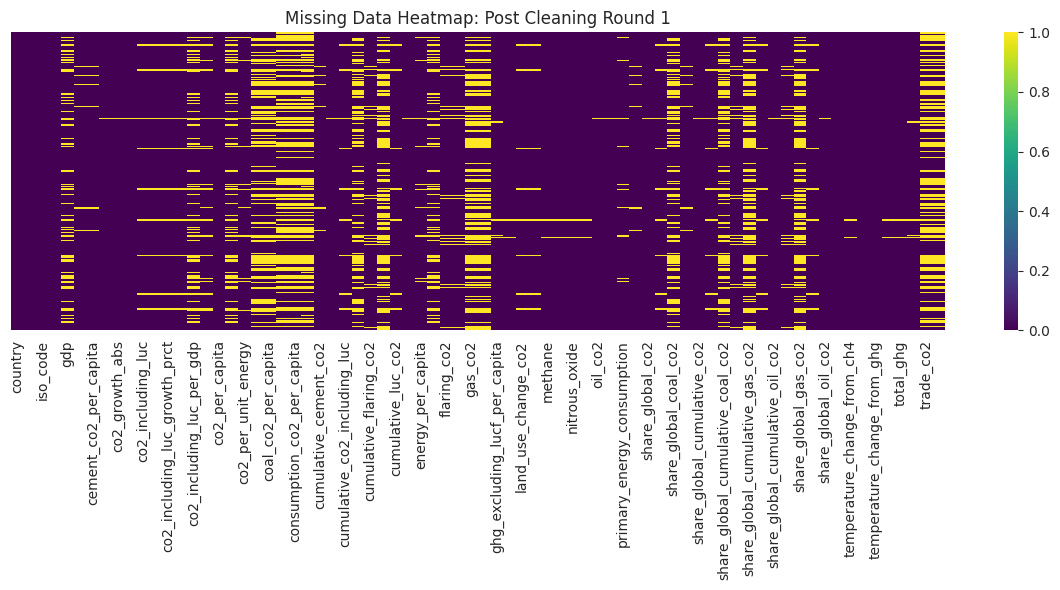

In [62]:
missing_pct_clean = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct_clean[missing_pct_clean > 0])
print('Percent of Total Data Missing: ', round(sum(missing_pct_clean[missing_pct_clean > 0])/77*100, 2), '%')

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap: Post Cleaning Round 1')
plt.tight_layout()
plt.show()

By manually parsing through the columns I have determined the best columns to focus on are:

['gdp', 'co2', 'co2_per_unit_energy', 'coal_co2', 'consumption_co2', 'energy_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'methane', 'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'share_global_co2', 'total_ghg', 'total_ghg_excluding_lucf', 'trade_co2']

I want to look at the heatmap of these to see which ones may need to be dropped.

In [63]:
df = df[['country', 'year', 'iso_code', 'population', 'gdp', 'co2', 'co2_per_unit_energy', 'coal_co2', 'consumption_co2', 'energy_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'methane', 'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'share_global_co2', 'total_ghg', 'total_ghg_excluding_lucf', 'trade_co2']]


Missing data (%) by column:
trade_co2                        0.422033
consumption_co2                  0.421891
coal_co2                         0.333049
gdp                              0.230704
co2_per_unit_energy              0.051741
primary_energy_consumption       0.044634
energy_per_capita                0.044634
land_use_change_co2              0.039801
ghg_excluding_lucf_per_capita    0.018053
total_ghg_excluding_lucf         0.018053
ghg_per_capita                   0.009950
total_ghg                        0.009950
methane                          0.009950
nitrous_oxide                    0.009950
oil_co2                          0.002701
co2                              0.001564
share_global_co2                 0.001564
dtype: float64
Percent of Total Data Missing:  2.17 %


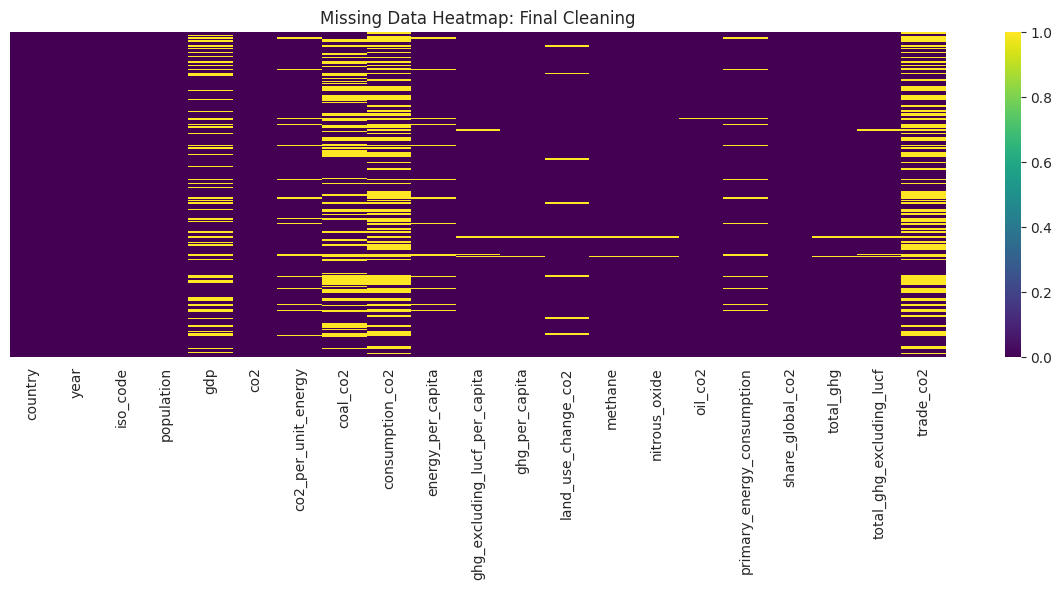

In [64]:
missing_pct_clean = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct_clean[missing_pct_clean > 0])
print('Percent of Total Data Missing: ', round(sum(missing_pct_clean[missing_pct_clean > 0])/77*100, 2), '%')

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap: Final Cleaning')
plt.tight_layout()
plt.show()

In [31]:
 # Dropping columns with more than 25% missing data (top 3: trade_co2, consumption co2, coal co2)

df = df[['country', 'year', 'iso_code', 'population', 'gdp', 'co2', 'co2_per_unit_energy', 'energy_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'methane', 'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'share_global_co2', 'total_ghg', 'total_ghg_excluding_lucf']]


### 2.4 Distribution Plots

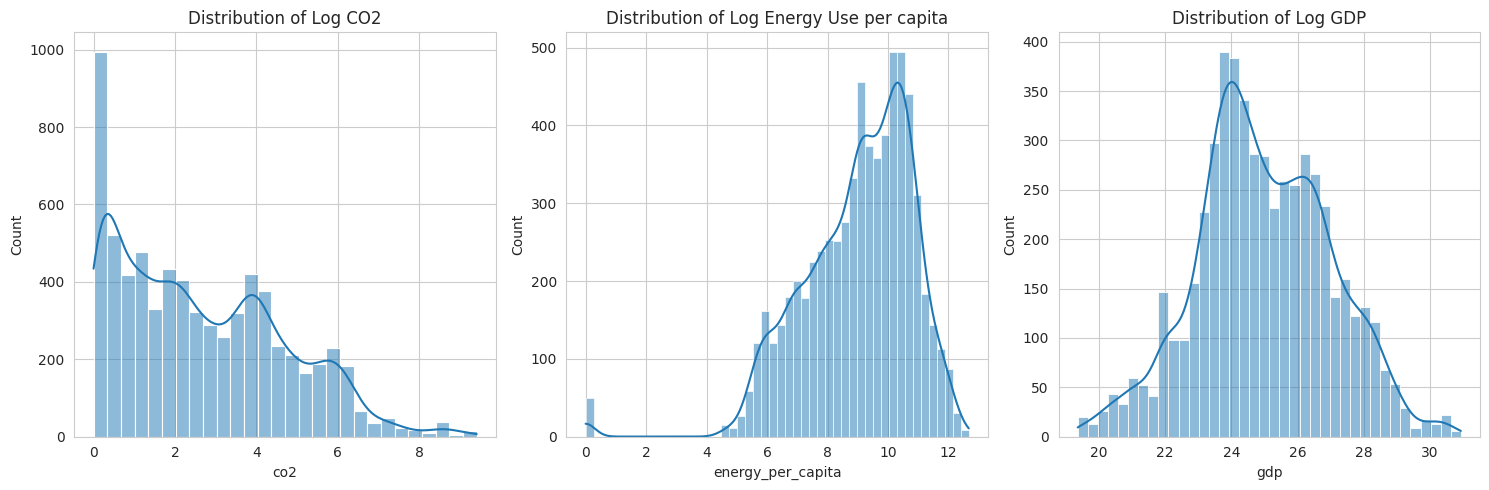

In [32]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

 # log transformed variables due to non-fitting
sns.histplot(np.log1p(df['co2']), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Log CO2')

sns.histplot(np.log1p(df['energy_per_capita']), kde=True, ax=axes[1])
axes[1].set_title('Distribution of Log Energy Use per capita')

sns.histplot(np.log1p(df['gdp']), kde=True, ax=axes[2])
axes[2].set_title('Distribution of Log GDP')

plt.tight_layout()
plt.show()

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7035 entries, 0 to 7034
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        7035 non-null   object 
 1   year                           7035 non-null   int64  
 2   iso_code                       7035 non-null   object 
 3   population                     7035 non-null   float64
 4   gdp                            5412 non-null   float64
 5   co2                            7024 non-null   float64
 6   co2_per_unit_energy            6671 non-null   float64
 7   energy_per_capita              6721 non-null   float64
 8   ghg_excluding_lucf_per_capita  6908 non-null   float64
 9   ghg_per_capita                 6965 non-null   float64
 10  land_use_change_co2            6755 non-null   float64
 11  methane                        6965 non-null   float64
 12  nitrous_oxide                  6965 non-null   f

### 2.5 Outlier Detection

In [47]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR


cols = df.select_dtypes(exclude='object')
outlier_count = 0
for i in cols:
  lower, upper = tukey_fences(df[i])
  outliers = df[(df[i] < lower) | (df[i] > upper)]
  outlier_count += len(outliers)
  print(f'{i}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')
print(f'There are {outlier_count} total outliers.')

year: 0 outliers (0.0%)
population: 818 outliers (11.6%)
gdp: 745 outliers (10.6%)
co2: 1047 outliers (14.9%)
co2_per_unit_energy: 462 outliers (6.6%)
energy_per_capita: 448 outliers (6.4%)
ghg_excluding_lucf_per_capita: 456 outliers (6.5%)
ghg_per_capita: 492 outliers (7.0%)
land_use_change_co2: 1032 outliers (14.7%)
methane: 903 outliers (12.8%)
nitrous_oxide: 782 outliers (11.1%)
oil_co2: 909 outliers (12.9%)
primary_energy_consumption: 970 outliers (13.8%)
share_global_co2: 1057 outliers (15.0%)
total_ghg: 995 outliers (14.1%)
total_ghg_excluding_lucf: 1080 outliers (15.4%)
There are 12196 total outliers.


**Outlier strategy:** I believe that we should keep the outliers. Although there are some outliers with countries that have co2 data, it likely that those are countries with high emission rates or at a time when emissions were higher. These number are important as the outliers would line up with periods higher economic growth (in theory). The other option would economies that have extremely low or no listed emission rate. This could be structural missing data. Low-income countries will likely not collect or report data like this. My data cleaning should have taken care of a majority of the missing data.

### 2.6 Correlations

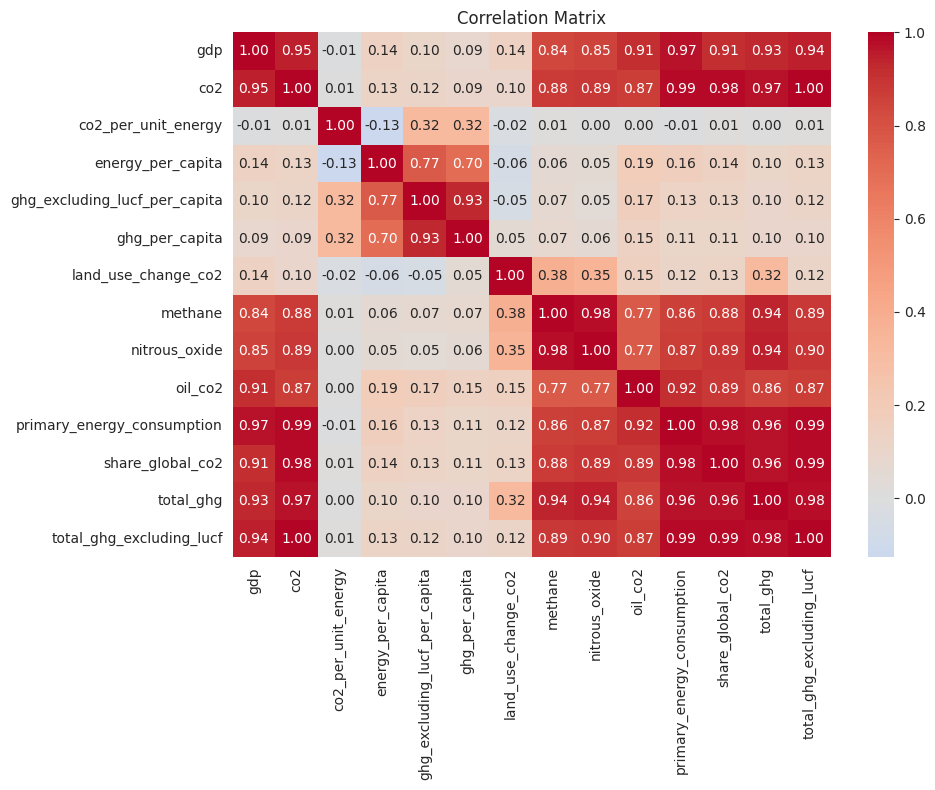

In [13]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

df_corr = df[['gdp', 'co2', 'co2_per_unit_energy', 'energy_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'methane', 'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'share_global_co2', 'total_ghg', 'total_ghg_excluding_lucf']]

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [48]:
 # Dropping redudant variables
df = df.drop(columns=['total_ghg_excluding_lucf', 'ghg_excluding_lucf_per_capita', 'share_global_co2', 'land_use_change_co2'])
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'co2',
       'co2_per_unit_energy', 'energy_per_capita', 'ghg_per_capita', 'methane',
       'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'total_ghg'],
      dtype='object')

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable has a low peak at zero with a long right skew. This may be due to the large amounts of missing data at the low end of the emission report, or because the developed and industrialized countries, which account for a large majority of total emissions, drag up the distribution.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* I only chose to test correlation with a small selection of variables which I felt would tell the best story and come closer the answering the question I am asking. GDP shows strong correlation with many emissions features including CO2, Oil CO2, and Total GHG (green house gas). I would be excited to select other feature to test with. After some further data searching and cleaning, it may be better to find a more comprehesive feature list.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest issue is the missing data. After cutting out variable with a significant amount of missing data (thresh=<50%), I plan to fill in the missing data with average of the two neighboring values. This may not be a great solution, but I am also searching for more comprehensive datasets that will have less missing values.

## EDA Questions re-answered Post Data Cleaning

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable has a two peaks, with a higher one just left of the center of the distribution and a smaller one to the right. There is also a light right skew. This may be due to the large amounts of missing data at the low end of the emission report, or because the developed and industrialized countries, which account for a large majority of total emissions, drag up the distribution.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* I only chose to test correlation with my selected features which I felt would tell the best story and come closer the answering the question I am asking. GDP shows strong correlation with many emissions features including CO2, methane, nitrous oxide, Oil CO2, primary energy consumption, share of global CO2, total GHG (green house gas), and total GHG.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest issue is the missing data. After cutting out variables with a significant amount of missing data (thresh=<50%), filling columns, and sorting to a small list of important columns I heva strong dataset. I plan to fill in the missing data with average of the two neighboring values using interpolating lambda functions. This may not be a great solution allows the data to be used by the regressions and any dashboards.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 50411** observations and **M = 77** features.

**Missing data:** 54.25% of cells are missing. The missingness pattern appears to be [MNAR] because non high-income (and high emission) countries will be more consistent about measuring this variables. I will handle missing data by cutting out largely missing features, and filling in gaps. It may also be helpful to focus on select countries that have more compelte data, but this may skew my results to be high-income country bias. Although, this bias may not matter given high-income countries are the large majority of emission either way.

**Outliers:** I identified 5229 outliers using [Tukey Fences]. I will handle them by figuring out if they are high-emission countries or missing data. I believe all data that is filled should be used since it is valuable and does not lose relavancy.

**Target variable:** The log distribution of GDP look normally distributed with a peak in the center.

**Key finding from EDA:** I think the biggest findings were the data issues that need to be patched, and the extremely strong correlation between GDP and emissions. This tells a good story and fits my original thoughts.

**Data Quality Summary post data-clean proper**

My dataset has **N = 7035** observations and **M = 18** features.

**Missing data:** 2.17% of cells are missing. The missingness pattern appears to be [MNAR] because non high-income (and high emission) countries will be more consistent about measuring this variables. I have handled missing data by cutting out largely missing features, missing or non-countries, filling in gaps, and cutting the time-frame (raw data started in 1750, but I dropped data from pre-1990 where emissions data started being recorded consistantly).

**Outliers:** I identified 1137 outliers across all the selected features using [Tukey Fences]. These outliers should be kept in the dataset because whether they are high-emission/high-GDP countries or low-emission/low-GDP countries, they are important to the understanding of the relationship.

**Target variable:** The target variable has a two peaks, with a higher one just left of the center of the distribution and a smaller one to the right. There is also a light right skew.

**Key finding from EDA:** I think the biggest findings were the data issues that have been patched, and the extremely strong correlation between GDP and emissions. This tells a good story and fits my original thoughts.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [15]:
 # Some of the data was not able to be cleaned fully, so I will interpolate to fill in the remaining gaps.
df = df.sort_values(['country', 'year'])

cols_to_interpolate = ['country', 'year', 'iso_code', 'population', 'gdp', 'co2',
       'co2_per_unit_energy', 'energy_per_capita', 'ghg_per_capita', 'methane',
       'nitrous_oxide', 'oil_co2', 'primary_energy_consumption', 'total_ghg']

for col in cols_to_interpolate:
    df[col] = df.groupby('country')[col].transform(lambda x: x.interpolate()).ffill().bfill()

df[cols_to_interpolate]

missing_pct_int = df[cols_to_interpolate].isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct_int)

/tmp/ipykernel_4242/1561844274.py:9: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[col] = df.groupby('country')[col].transform(lambda x: x.interpolate()).ffill().bfill()
/tmp/ipykernel_4242/1561844274.py:9: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[col] = df.groupby('country')[col].transform(lambda x: x.interpolate()).ffill().bfill()


Missing data (%) by column:
country                       0.0
year                          0.0
iso_code                      0.0
population                    0.0
gdp                           0.0
co2                           0.0
co2_per_unit_energy           0.0
energy_per_capita             0.0
ghg_per_capita                0.0
methane                       0.0
nitrous_oxide                 0.0
oil_co2                       0.0
primary_energy_consumption    0.0
total_ghg                     0.0
dtype: float64


In [16]:
df['gdp_log'] = np.log1p(df['gdp'])
df['co2_log'] = np.log1p(df['co2'])
df['methane_log'] = np.log1p(df['methane'])
df['nitrous_oxide_log'] = np.log1p(df['nitrous_oxide'])
df['oil_co2_log'] = np.log1p(df['oil_co2'])
df['primary_energy_consumption_log'] = np.log1p(df['primary_energy_consumption'])
df['total_ghg_log'] = np.log1p(df['total_ghg'])

In [17]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# df_corr = df[['year', 'gdp', 'co2', 'ghg_per_capita', 'oil_co2', 'total_ghg', 'trade_co2']]

# Define features and target
X = df[['co2_log', 'co2_per_unit_energy', 'energy_per_capita', 'ghg_per_capita',
        'methane_log', 'nitrous_oxide_log', 'oil_co2_log',
        'primary_energy_consumption_log', 'total_ghg_log']]  # Replace with your features
y = df['gdp_log']  # Replace with your target

# For classification: use stratify=y
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
# )

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

 # Scaling data due to variation in range of different features.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f'Train: {X_train_scaled.shape[0]} samples')
print(f'Test:  {X_test_scaled.shape[0]} samples')

Train: 5628 samples
Test:  1407 samples


### 3.2 Model 1: Baseline

In [18]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
  # Regression: LinearRegression or Ridge

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)

y_pred_1 = model_1.predict(X_test_scaled)

# # Classification metrics
# print('Model 1: Logistic Regression')
# print(classification_report(y_test, y_pred_1))

# Regression metrics (use these instead if regression)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_1):.4f}')

RMSE: 1.3356
MAE:  0.9127
R²:   0.5453


### 3.3 Model 2: Your Choice

In [19]:
 # I believe a Ridge model would be a great next step between OLS and Random Forest.
 # It will also be interesting to compare the three and how they weight the coefficients.

from sklearn.linear_model import Ridge, RidgeCV

ridge_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000])
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print(f'Best Alpha: {ridge_model.alpha_}')
print(f'RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_ridge):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_ridge):.4f}')


Best Alpha: 100.0
RMSE:  1.3338
MAE:  0.9107
R²:   0.5466


In [20]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestRegressor
#
model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
#
y_pred_2 = model_2.predict(X_test)
#
print('Model 2: Random Forest')
print(f'RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest
RMSE:  0.4440
MAE:  0.1881
R²:   0.9498


### 3.4 Cross-Validation Comparison

In [49]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
scoring = 'r2'
#
cv_1 = cross_val_score(model_1, X_train_scaled, y_train, cv=5, scoring=scoring)
cv_ridge = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Ridge Model CV {scoring}: {cv_ridge.mean():.4f} +/- {cv_ridge.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Ridge Model', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_ridge.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_ridge.std(), cv_2.std()],
})
comparison

Model 1 CV r2: 0.5313 +/- 0.0229
Ridge Model CV r2: 0.5291 +/- 0.0220
Model 2 CV r2: 0.9568 +/- 0.0046


,Model,CV r2 (mean),CV r2 (std)
0,Model 1 (Baseline),0.531329,0.022939
1,Ridge Model,0.529079,0.021978
2,Model 2 (Random Forest),0.956781,0.004592


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

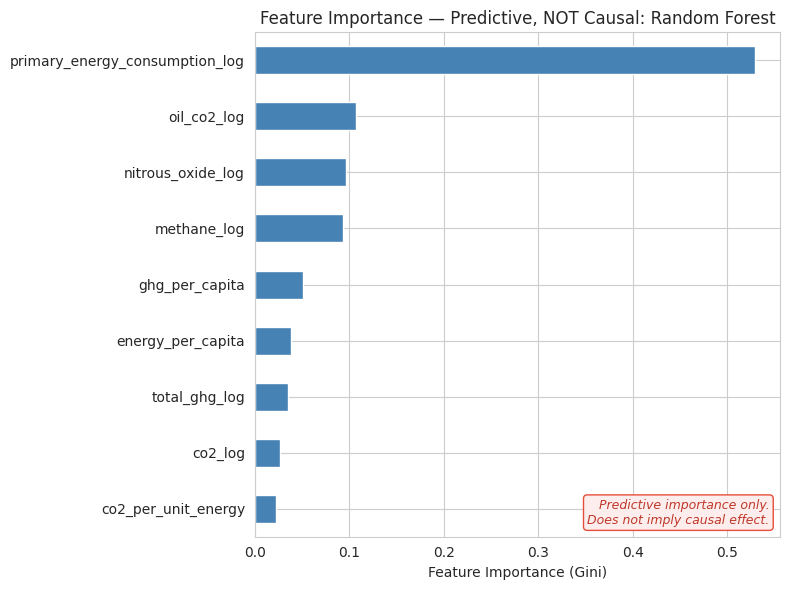

In [54]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# For tree-based models:
importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal: Random Forest')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

This is concerning that one feature has taken over, but it does not surpise me. Many of the features were strongly correlated with GDP so a forest model may choose the more correlated and learn that relationship. I will test a Gradiant Boosting model to see if the results improve.

In [51]:
from sklearn.ensemble import GradientBoostingRegressor
#
model_gb = GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_gb.fit(X_train, y_train)
#
y_pred_gb = model_gb.predict(X_test)
#
print('Model 2: Random Forest')
print(f'RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_gb):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_gb):.4f}')

Model 2: Random Forest
RMSE:  0.7646
MAE:  0.4791
R2:   0.8510


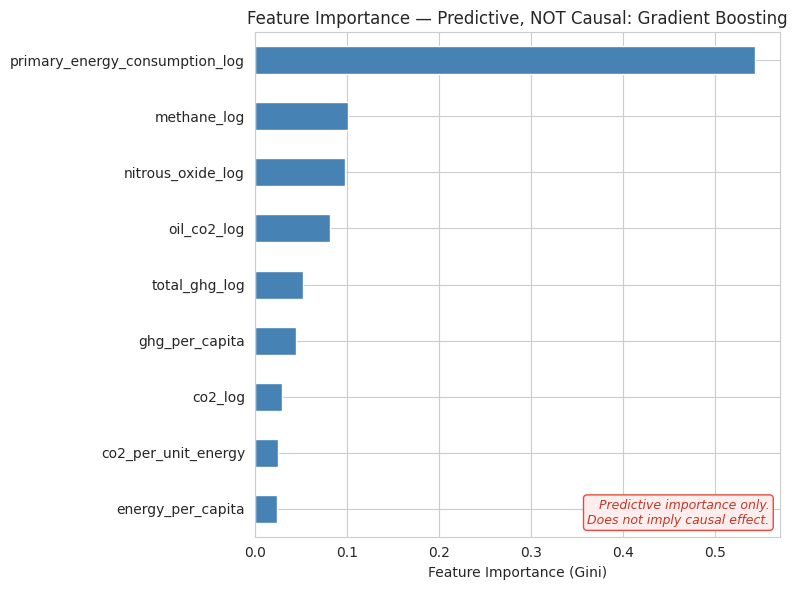

In [55]:
# For tree-based models:
importances = pd.Series(
    model_gb.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal: Gradient Boosting')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

The Gradient Boosting model performed worse than the Random Forest model. Across the board, the RMSE, MAE, and R2 were worse. Along with that, the feature importance, with slight, become more reliant on `primary_energy_consumption_log`. This tell me that RF was the correct choice

### 4.2 Key Visualization for Your Report

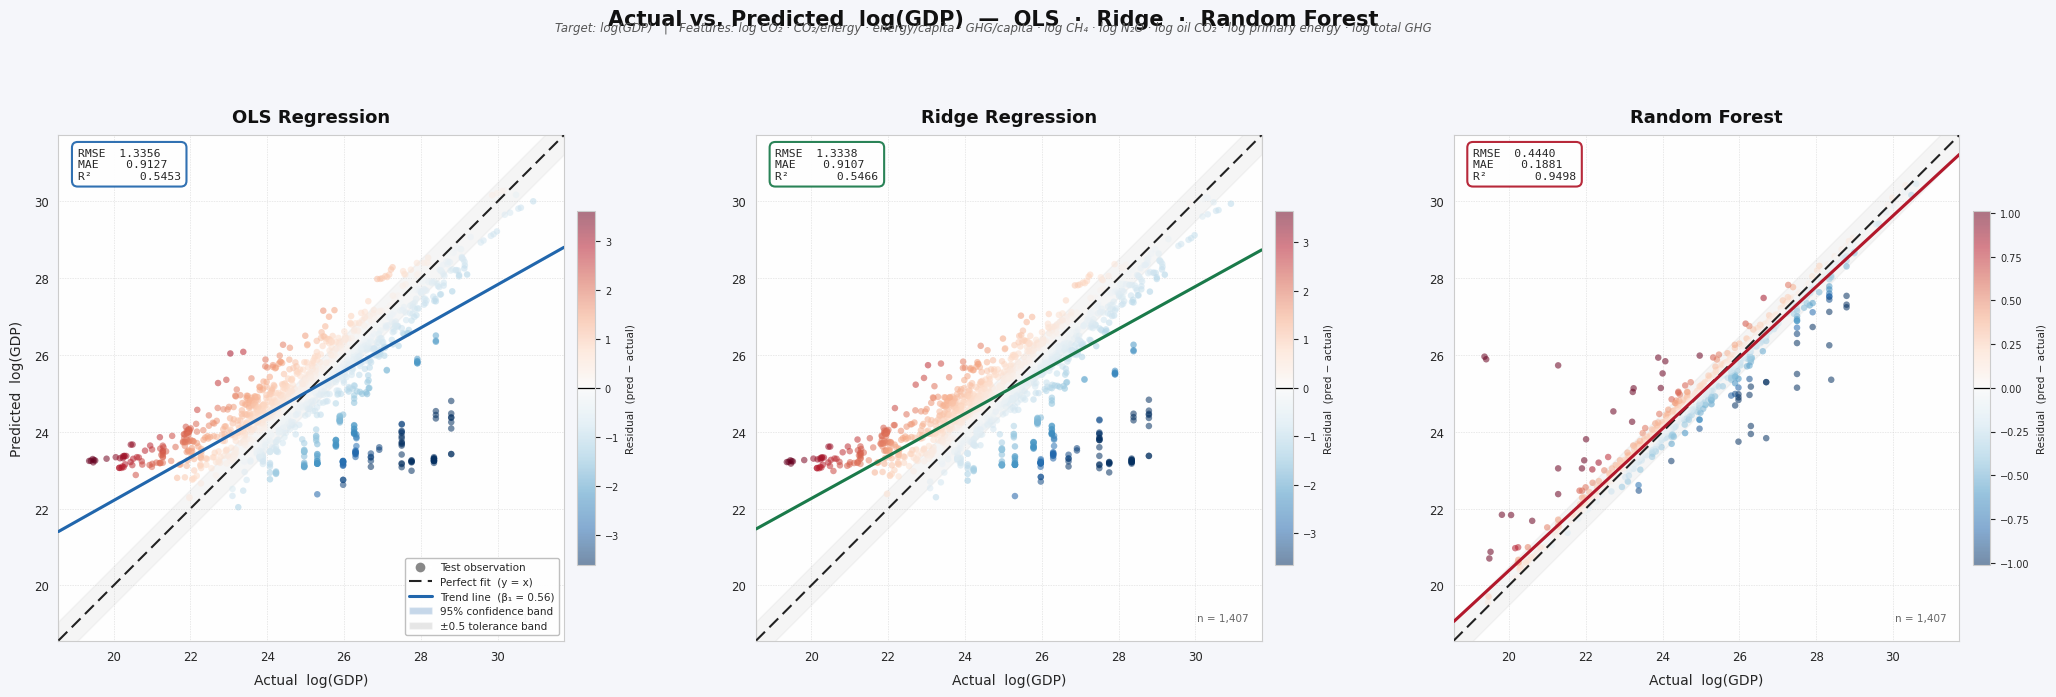

In [53]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Assumes these variables already exist from the cells above ────────────────
#   y_test       : true log(GDP) values on the held-out test set
#   y_pred_1     : OLS predictions (from model_1.predict(X_test_scaled))
#   y_pred_ridge : Ridge predictions (from ridge_model.predict(X_test_scaled))
#   y_pred_2     : Random Forest predictions (from model_2.predict(X_test))
# Convert to numpy arrays to ensure consistent behaviour regardless of whether
# they came out of sklearn as arrays or pandas Series.
y_test       = np.array(y_test)
y_pred_ols   = np.array(y_pred_1)
y_pred_ridge = np.array(y_pred_ridge)
y_pred_rf    = np.array(y_pred_2)

# ── Metrics helper ────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    """Return RMSE, MAE, and R² as a dict. RMSE uses mean_squared_error
    (not mean_absolute_error) — corrects the formula used in the cells above."""
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE' : mean_absolute_error(y_true, y_pred),
        'R²'  : r2_score(y_true, y_pred),
    }

# ── Model definitions ─────────────────────────────────────────────────────────
# Each dict carries the display label, the prediction array, and a panel colour.
models = [
    {'label': 'OLS Regression',   'preds': y_pred_ols,   'color': '#2166AC'},
    {'label': 'Ridge Regression', 'preds': y_pred_ridge, 'color': '#1A7A4A'},
    {'label': 'Random Forest',    'preds': y_pred_rf,    'color': '#B2182B'},
]

# ── Shared axis limits ────────────────────────────────────────────────────────
# All three panels share the same range so models are directly comparable.
# Padded slightly beyond the data range for visual breathing room.
pad    = 0.8
ax_min = y_test.min() - pad
ax_max = y_test.max() + pad

# ── Per-model residual colour normalisation ───────────────────────────────────
# Normalise each panel independently so within-model residual spread is always
# visible. A global norm would compress the RF residuals (much smaller) into a
# near-white band, hiding the few mis-predictions the model does make.
def make_norm(residuals):
    cap = np.percentile(np.abs(residuals), 97)  # clip top-3% outliers
    return plt.Normalize(vmin=-cap, vmax=cap)

# ── Figure and layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(21, 7.5))
fig.patch.set_facecolor('#F5F6FA')

fig.suptitle(
    'Actual vs. Predicted  log(GDP)  —  OLS  ·  Ridge  ·  Random Forest',
    fontsize=15, fontweight='bold', y=1.005, color='#111111'
)
fig.text(
    0.5, 0.975,
    'Target: log(GDP)   |   Features: log CO₂ · CO₂/energy · energy/capita · '
    'GHG/capita · log CH₄ · log N₂O · log oil CO₂ · log primary energy · log total GHG',
    ha='center', fontsize=8.5, color='#555555', style='italic'
)

# 1×3 grid with controlled spacing
gs = gridspec.GridSpec(
    1, 3, figure=fig,
    wspace=0.30,
    left=0.055, right=0.975,
    top=0.88,   bottom=0.12
)

# ── One panel per model ───────────────────────────────────────────────────────
for col_idx, m in enumerate(models):

    ax        = fig.add_subplot(gs[0, col_idx])
    y_pred    = m['preds']
    color     = m['color']

    # Residual = predicted minus actual.
    # Positive → model over-predicted; negative → model under-predicted.
    residuals = y_pred - y_test
    norm      = make_norm(residuals)
    cmap      = plt.cm.RdBu_r   # red = over-pred, blue = under-pred, white = on target

    # ── Scatter: each point is one country-year observation ──────────────────
    sc = ax.scatter(
        y_test, y_pred,
        c=residuals, cmap=cmap, norm=norm,
        s=22, alpha=0.55, edgecolors='none', zorder=3,
        rasterized=True   # rasterise dense scatter for smaller file size
    )

    # ── Perfect-prediction reference line (y = x) ────────────────────────────
    # Points on this line have zero prediction error.
    ax.plot(
        [ax_min, ax_max], [ax_min, ax_max],
        color='#222222', linewidth=1.5, linestyle='--', dashes=(6, 3),
        zorder=5, label='Perfect fit  (y = x)'
    )

    # ── Trend line: OLS fit of predicted on actual ────────────────────────────
    # Slope β₁ < 1 signals compression bias — the model under-predicts high
    # values and over-predicts low values (regression toward the mean).
    slope, intercept, _, _, se_slope = stats.linregress(y_test, y_pred)
    x_line = np.linspace(ax_min, ax_max, 300)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line,
        color=color, linewidth=2.2, linestyle='-',
        zorder=6, label=f'Trend line  (β₁ = {slope:.2f})'
    )

    # ── 95% confidence band around the trend line ────────────────────────────
    n      = len(y_test)
    x_mean = y_test.mean()
    se_hat = se_slope * np.sqrt(
        1/n + (x_line - x_mean)**2 / ((y_test - x_mean)**2).sum()
    )
    t_crit = stats.t.ppf(0.975, df=n - 2)
    ax.fill_between(
        x_line,
        y_line - t_crit * se_hat,
        y_line + t_crit * se_hat,
        color=color, alpha=0.13, zorder=2,
        label='95% confidence band'
    )

    # ── ±0.5 log-unit tolerance band ─────────────────────────────────────────
    # Shades the region where |residual| < 0.5. In log(GDP) terms, a 0.5-unit
    # error corresponds roughly to a factor-of-1.6 error in GDP levels, which
    # serves as a practical "acceptable" error threshold.
    ax.fill_between(
        [ax_min, ax_max],
        [ax_min - 0.5, ax_max - 0.5],
        [ax_min + 0.5, ax_max + 0.5],
        color='#AAAAAA', alpha=0.10, zorder=1,
        label='±0.5 tolerance band'
    )

    # ── Metrics box (top-left of each panel) ─────────────────────────────────
    mtr = get_metrics(y_test, y_pred)
    box_text = (
        f"RMSE  {mtr['RMSE']:.4f}\n"
        f"MAE    {mtr['MAE']:.4f}\n"
        f"R²       {mtr['R²']:.4f}"
    )
    ax.text(
        0.038, 0.975, box_text,
        transform=ax.transAxes,
        fontsize=8.2, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(
            boxstyle='round,pad=0.50',
            facecolor='white', edgecolor=color,
            linewidth=1.5, alpha=0.93
        ),
        zorder=10
    )

    # Sample count (bottom-right of each panel)
    ax.text(
        0.975, 0.035, f'n = {n:,}',
        transform=ax.transAxes,
        fontsize=7.5, ha='right', va='bottom', color='#666666'
    )

    # ── Colourbar ─────────────────────────────────────────────────────────────
    cbar = fig.colorbar(sc, ax=ax, fraction=0.033, pad=0.025, shrink=0.90)
    cbar.set_label('Residual  (pred − actual)', fontsize=7.5, labelpad=5)
    cbar.ax.tick_params(labelsize=7)
    cbar.ax.axhline(0, color='black', linewidth=0.9)  # zero residual marker

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(ax_min, ax_max)
    ax.set_ylim(ax_min, ax_max)
    ax.set_aspect('equal', adjustable='box')   # keeps the y=x line at 45°
    ax.set_title(m['label'], fontsize=13, fontweight='bold',
                 color='#111111', pad=9)
    ax.set_xlabel('Actual  log(GDP)', fontsize=10, labelpad=7)

    # Y-axis label only on the leftmost panel to avoid repetition
    ax.set_ylabel('Predicted  log(GDP)' if col_idx == 0 else '',
                  fontsize=10, labelpad=7)

    ax.tick_params(labelsize=8.5)
    ax.set_facecolor('#FEFEFE')
    ax.grid(True, linestyle=':', linewidth=0.45, color='#CCCCCC', zorder=0)
    ax.set_axisbelow(True)

    # Light grey spines
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.8)

    # ── Legend — left panel only ──────────────────────────────────────────────
    if col_idx == 0:
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markersize=7,
                   markerfacecolor='#888888', markeredgecolor='none',
                   label='Test observation'),
            Line2D([0], [0], color='#222222', linewidth=1.5,
                   linestyle='--', dashes=(6, 3),
                   label='Perfect fit  (y = x)'),
            Line2D([0], [0], color=color, linewidth=2.2,
                   label=f'Trend line  (β₁ = {slope:.2f})'),
            Patch(facecolor=color, alpha=0.25,
                  label='95% confidence band'),
            Patch(facecolor='#AAAAAA', alpha=0.28,
                  label='±0.5 tolerance band'),
        ]
        ax.legend(
            handles=legend_handles,
            fontsize=7.5, loc='lower right',
            framealpha=0.93, edgecolor='#BBBBBB',
            handlelength=2.2, labelspacing=0.45
        )

plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** The data is from Our World in Data, a project built on a collboration between researchers at the University of Oxford and the non-profit organisation Global Change Data Lab. This data is the premiere data source, used by the World Bank. This project show us the predictive power of regressions ran on emissions and GDP data. We are trying to see if GDP can be predicted based on emissions, and from there tell if emission rates positively impact GDP. Environmental economists would be interested in this research because they would be able to critically analyze which emissions have the strongest correlation to GDP. From this, they would be able to determine whether the cost of emissions is worth gain from economic growth. Balance social, public, and private costs is an ongoing issue that is controversial in the economic and policial space.

**Complication:** Deciding the costs and benefits of emsissions are a difficult task. On one hand, emissions cause permenant damange to the environment, having large consequences including global warming/climate change, ecological damage, polluted air, and more. We have already seen many of these consequences take a toll on the earth. On the other hand, emissions are a huge, and sometimes unavoidable part of economic progress. We have relied on fossil fuels, polluting industries, and consumerist ideals to run homes, businesses, and the global progress. Not being able to emit any pollutants would halt the global economy. While some polluting parties may be able to find alternative methods, there cannot operate without pollutants. Global shipping, electricity, commodities, financial markets, AI, and more would collaspe if they were not able to pollute at all.

This research project revealed that our current economy is intertwined with emissions. Global emissions could not be seperated out from GDP, and their colinearity depicts a detrimental symbiotic relationship.

**Resolution:** Many scientist estimate that we are mere years away from polluting the environment beyond repair. It is constantly theorized that our enviornmental damange will an ending for to earth (and potentially humanity). You must think of it as an economic bubble. The data, both the models and the correlation structure of the features show that emissions are tied closely to GDP. This is espically true for stronger economies where the high GDP and high emissions go hand-in-hand. Our current regulations do not consider these risks. With the recent repeal of the 2009 Greenhouse Gas Endangerment Finding, which removed the legal basis for regualting greenhouse gases, we can see that long-term social cost are not being considered.

**Uncertainty Statement:** Based on our cross-validation results (R² = 0.9568 +/- 0.0046), we estimate that the Random Forest model is able to correctly predict 95.68% of the variance in log-GDP, giving it strong predictive power. The primary limitation is the dominance and mutlicolinearity of the features. Given that the features were strongly correlated to the target variables, it is likely that the model is learning that pattern of the most correlated variables and using the remaining features to tune up the remaining residuals. We recommend policy makers use the model for predictive applications on the effects of lower emissions on GDP with the caveat that policy should be examined through fixed-effects strategies that are able to isolate the effects.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

*Please see the AI appendix for the full interactions*
---

### AI Interaction 1

Prep: You are an environmental economist working at the world bank. You were tasked with understanding the relationship between energy usage, emissions, and GDP growth. You are given the dataset from the world bank. Here is the link: https://raw.githubusercontent.com/owid/co2-data/refs/heads/master/owid-co2-data.csv. I will also upload the current code so you know where the project is currently.

Request: There is a significant amount of missing data, both across time and countries. Given the missing data, I would like to fill and fix the NaN in order to run proper analyses on the data. I believe this data to be MAR (Missing at Random). Most of the missing data would be from times/countries with inaccurate records. I think the best solution is to take out countries with large amounts of NaN and years with large amounts of NaNs, and then fill the rest with the average of the value most recently before the NaN and most recently after. Could you provide the proper code and documentation for that?

Iterate: Please iterate through the data to ensure its accuracy and completeness. It needs to be ready to use in complex ML regressions, streamlit dashboards and more. Please include comments explaining any code.

Mechanism Check: If you do not believe this method is the best, why and what would your other suggestions be? If you do, continue. It is important to have complete and accurate data, but missing data can cause problems.

Evaluate: I am looking for the data to be output in a complete pandas DataFrame that is ready to be used in any regression or dashboard and ready to be displayed.


---

### AI Interaction 2

Prep: You are an environmental economist working at the world bank. You were tasked with understanding the relationship between energy usage, emissions, and GDP growth. You are given the dataset from the world bank. Use the cleaned CSV file that was developed previously. You will be given code that contains an OLS regression that was run as a baseline, a Ridge regression run as an intermediary step, and a Random Forest regression.

Request: Please write the python code for a scatter plot that compares the three different regressions where the predicted value is compared to the real value. Use matplotlib, seaborn, pyplot, or any other graphing software that will depict the regressions professionally and cleanly. Convert scaled data or use the unscaled variables, depending on what is deemed better for interpretability. Place the graphs on a 1x3 subplot grid where the y_test is on the x-axis and the predicted y is on the y-axis. Include fitted lines, reference lines, regression lines on the graphs. Color points based on residual. Mark each point with relevant information when hovered over. Include metrics about the plot on the graph. Include a legend.

Iterate: Make sure that the plot is visually clean and readable. Run the code and view the plots for any unclear or low-readability parts that can be fixed. Ensure the points are distinct and the whole picture is clear. Please include comments explaining any code. If there are any additional items that you believe may be beneficial to the plot please add them as well.

Mechanism Check: Ensure that the pattern of the regressions is clear and displayed professionally. The models should also align with the tested and displayed metrics.

Evaluate: Explain what the regression analysis reveals about the different models and their relationship to each other.

---

### AI Interaction 3

Prep: You are an environmental economist working at the world bank. You were tasked with understanding the relationship between energy usage, emissions, and GDP growth. You will work with the cleaned OWID csv dataset, an ipynb file (uploaded as: 3916_final_project_starter.ipynb) that has 3 regressions, and a small analysis on the importance of the work. You have created these regressions and analysis and are looking to create a Streamlit dashboard to display your findings and research to colleagues and policy makers.

Request: Please create a comprehensive and dynamic Streamlit dashboard in an app.py format that is able to be deployed, first locally in the Google Colab notebook then uploaded to a github repository where it will be deployed live. The overall structure of the dashboard must have a data overview section that displayed the cleaned OWID CSV that is used in the regressions in a table format, an interactive model view where users are able to view the three different regression models and view how they change when features are taken or added, and a predictive section where users are able to choose their model and inputs and it shows a predictive output. These must be in different tabs using st.tabs(). It must contain the following:
 - [In the data overview section] title and description using: st.title(), st.markdown(). The title should remain displayed on top regardless of the tab/display the user is viewing
 - [In the predictive section] Input controls using st.slider(), st.selectbox(), st.number_input(). These controls should be in a sidebar where the user is able to select the model, and a slider for the input features. Ensure the input features are clearly labeled with their sliders. Sliders must be in a comprehensible format (e.g. a slider for co2_log is not as understandable as co2. please make the backend data convert the user’s non-log input into the input for regression’s depiction). Be careful about feature order and scaling.
 - The models loaded must be the trained models from the .ipynb file given
 - [In the predictive section] please display the confidence/prediction intervals alongside point estimates. Use the library MAPIE to wrap the sklearn models and get the prediction intervals for display.
 - Along with that create a requirements.txt showing all Python dependencies with version pins formatted like this:

streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
 - The model should be saved using joblib, like joblib.dump(model_2, 'model.pkl'), and loaded using ‘@st.cachce_resource’. Plots should use plotly, especially for the interactive visualizations.

Iterate: Please run and test the Streamlit dashboard as if you were a user in a local sandbox. Ensure that the dashboard’s writing, labels, buttons, and visuals are clear, readable, and professional. Ensure that the different required sections are accessible on different tabs of the dashboard. This dashboard is to be used by experts and non-experts and must be comprehensive yet approachable. Please include comments explaining any code. The code must be given to me in a format that is ready to paste into a Google Colab notebook for me to test locally and then deploy onto Steamlit live.

Mechanism Check: The regression displays should show the relationships between the various features and the target variable of GDP.

Evaluate: Please ensure the interactive elements work well and seamlessly blend with the visualizations. The dashboard should update in a few seconds for each slider. Use ‘@st.cachce_resource’ to load the dashboard and ensure it does not surpass the 1GB RAM limit.
